In [24]:
!pip install tensorflow matplotlib pandas numpy opencv-python


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: C:\Medical-Image-Classifier\venv\Scripts\python.exe -m pip install --upgrade pip


In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224) 

print("Loading Training Data...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'data/train',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

print("\nLoading Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    'data/val',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

class_names = train_dataset.class_names
print(f"\nClasses found: {class_names}")

Loading Training Data...
Found 5216 files belonging to 2 classes.

Loading Validation Data...
Found 16 files belonging to 2 classes.

Classes found: ['NORMAL', 'PNEUMONIA']


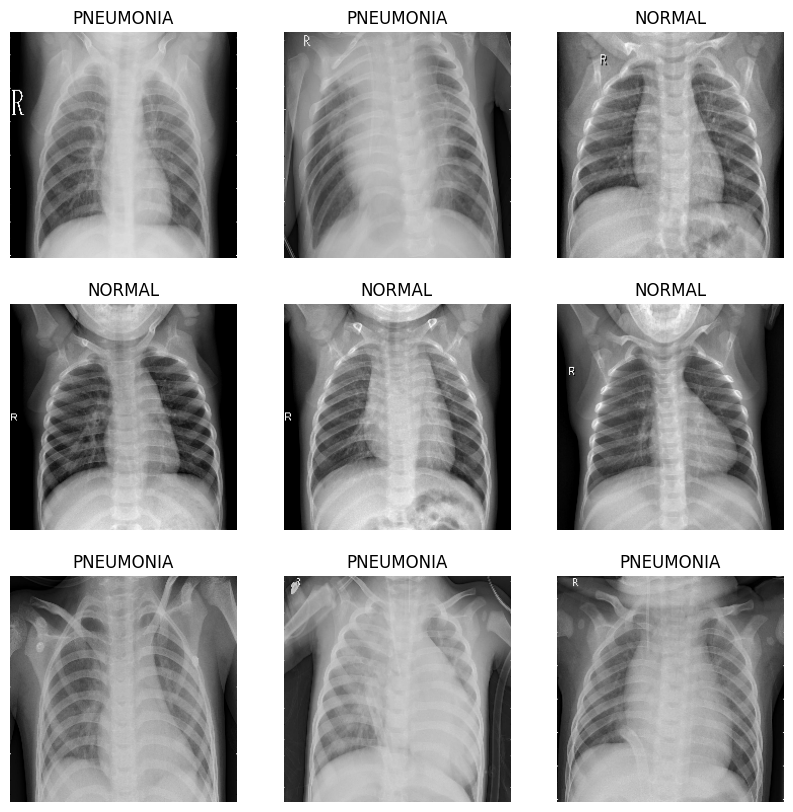

In [26]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert pixel values back to standard integers for displaying
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

print("Step 1: Building the Deep Learning Model...")

# 1. Load the pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze the base model

# 2. Build our custom Medical Classifier on top
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(1, activation='sigmoid') 
])

# 3. Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)
print("Model built successfully! Moving to training...\n")

# 4. Train the model for 5 passes (epochs) over the dataset
print("Step 2: Starting Model Training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

# 5. Save the trained model to your computer
model.save("pneumonia_classifier.keras")
print("Model saved successfully as pneumonia_classifier.keras!")

Step 1: Building the Deep Learning Model...
Model built successfully! Moving to training...

Step 2: Starting Model Training...
Epoch 1/5
 19/163 ━━━━━━━━━━━━━━━━━━━━ 11:12 5s/step - accuracy: 0.7632 - loss: 12.5447

KeyboardInterrupt: 

In [ ]:
print("Loading Test Data for Final Evaluation...")

# It is crucial that shuffle=False here so the labels match up perfectly
test_dataset = tf.keras.utils.image_dataset_from_directory(
    'data/test',
    shuffle=False, 
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

print("\nGrading the Model on Unseen Data...")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\n🏆 Final Test Accuracy: {test_acc * 100:.2f}%")

Loading Test Data for Final Evaluation...
Found 624 files belonging to 2 classes.

Grading the Model on Unseen Data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.7901 - loss: 1.3480

🏆 Final Test Accuracy: 79.01%


In [ ]:
!pip install scikit-learn seaborn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc44


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: C:\Medical-Image-Classifier\venv\Scripts\python.exe -m pip install --upgrade pip


In [28]:
import tensorflow as tf

print("Loading the saved model...")
# Load the pre-trained brain from your hard drive
model = tf.keras.models.load_model("pneumonia_classifier.keras")
print("Model loaded successfully! You can now skip the training cell.")

Loading the saved model...
Model loaded successfully! You can now skip the training cell.


In [30]:
%pip install seaborn scikit-learn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc44


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Generating predictions on the test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step


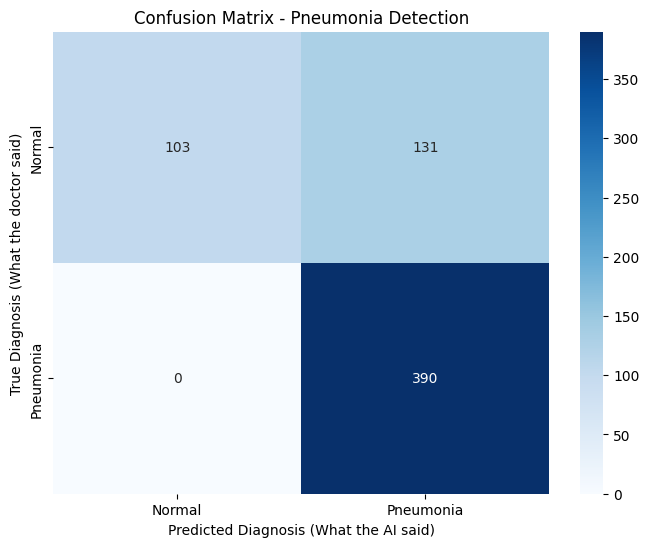


--- Detailed Diagnostic Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.44      0.61       234
   Pneumonia       0.75      1.00      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.72      0.73       624
weighted avg       0.84      0.79      0.76       624



In [31]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions on the test data...")
# 1. Have the model predict the diagnosis for all 624 test images
predictions = model.predict(test_dataset)
# Convert percentage probabilities into strict 0 (Normal) or 1 (Pneumonia) predictions
predicted_classes = np.where(predictions > 0.5, 1, 0)

# 2. Get the actual, true labels from the dataset to compare
true_classes = np.concatenate([y for x, y in test_dataset], axis=0)

# 3. Calculate the Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 4. Draw the colorful Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - Pneumonia Detection')
plt.ylabel('True Diagnosis (What the doctor said)')
plt.xlabel('Predicted Diagnosis (What the AI said)')
plt.show()

# 5. Print a detailed statistical report
print("\n--- Detailed Diagnostic Report ---")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))